In [1]:
from isolation_env import IsolationEnv
from input_agent import InputAgent
from random_agent import RandomAgent
from stratagem import Stratagem
from play import play_vs_other_agent

In [2]:
env = IsolationEnv()
input_agent = InputAgent()
env.action_space

Discrete(9)

Input Agents

In [3]:
#play_vs_other_agent(env, agent1=input_agent, agent2=input_agent)

Random Agents

In [4]:
play_vs_other_agent(env, agent1=RandomAgent(1), agent2=RandomAgent(2), render=True)

+-----+-----+-----+-----+-----+
|     | 0   | 1   | 2   | 3   |
+=====+=====+=====+=====+=====+
|   0 |     |     |     | B   |
+-----+-----+-----+-----+-----+
|   1 |     |     |     |     |
+-----+-----+-----+-----+-----+
|   2 |     |     |     |     |
+-----+-----+-----+-----+-----+
|   3 |     | R   |     |     |
+-----+-----+-----+-----+-----+
+-----+-----+-----+-----+-----+
|     | 0   | 1   | 2   | 3   |
+=====+=====+=====+=====+=====+
|   0 |     |     |     | X   |
+-----+-----+-----+-----+-----+
|   1 |     |     |     | B   |
+-----+-----+-----+-----+-----+
|   2 |     |     |     |     |
+-----+-----+-----+-----+-----+
|   3 | X   | R   |     |     |
+-----+-----+-----+-----+-----+
+-----+-----+-----+-----+-----+
|     | 0   | 1   | 2   | 3   |
+=====+=====+=====+=====+=====+
|   0 |     |     |     | X   |
+-----+-----+-----+-----+-----+
|   1 |     |     |     | B   |
+-----+-----+-----+-----+-----+
|   2 |     | R   | X   |     |
+-----+-----+-----+-----+-----+
|   3 | 

Random Agent vs Stratagem

In [5]:
play_vs_other_agent(env, agent1=RandomAgent(1), agent2=Stratagem(2))

Player 2 WON


# Experimentos MATE - busqueda adversarial sobre Isolation

Esta seccion agrega a las demos anteriores los experimentos **E1-E6** del proyecto MATE,
usando los agentes implementados (`MinimaxAgent`, `ExpectimaxAgent`), las heuristicas de
`evaluation.py` y el runner reproducible `play_match` de `match.py`.

**Metodologia (resumen).** Diseno **apareado**: cada seed se juega **dos veces** (nuestro
agente de jugador 1 y de jugador 2) con la **misma colocacion inicial**, lo que controla la
posicion y la **ventaja de primer jugador**. Se promedian los resultados. Se mide el costo
**por agente** (`a_avg_move_time`, `a_nodes_per_move`), no solo el promedio del juego. Todo
se registra en `results.csv`. Justificacion en `Documentacion/DocumentacionMATE.md` (seccion 4).

> **Corrida final.** Seeds: `N_RANDOM=100`, `N_SELF=100`, `N_STRAT=40`, `N_HEUR=30` (cada
> seed = 2 partidas, una por lado). E3 compara ambas tecnicas vs Stratagem a **d=2 y d=3**.
> Para iterar rapido, bajar estas constantes en la celda de configuracion.

In [6]:
import time, random, itertools, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from board import Board
from isolation_env import IsolationEnv
from random_agent import RandomAgent
from stratagem import Stratagem
from minimax_agent import MinimaxAgent
from expectimax_agent import ExpectimaxAgent
from evaluation import weighted_eval, HEURISTICS
from match import play_match

# ----- Configuracion de los experimentos (corrida final, diseno apareado) -----
# Cada "seed" se juega DOS veces (nuestro agente de jugador 1 y de jugador 2) con la MISMA
# colocacion inicial -> comparacion apareada que controla la posicion y la ventaja de primer
# jugador. Por eso: partidas por lado = numero de seeds; total por matchup = 2 x seeds.
BASE_SEED    = 1000          # semilla base; el seed k-esimo es BASE_SEED + k
DEPTH        = 2             # profundidad de juego por defecto (Minimax/Expectimax)
N_RANDOM     = 100           # seeds vs RandomAgent          (-> 200 partidas, 100/lado)
N_STRAT      = 40            # seeds vs Stratagem            (-> 80 partidas, 40/lado; lento)
N_SELF       = 100           # seeds Minimax vs Expectimax   (-> 200 partidas)
N_HEUR       = 30            # seeds por par (torneo heur.)  (-> 60 partidas/par)
AB_DEPTHS    = [1, 2, 3, 4]  # profundidades para el estudio de Alpha-Beta (E1)
AB_POSITIONS = 6             # posiciones de prueba para E1
E3_DEPTHS    = [2, 3]        # E3 mide ambas tecnicas vs Stratagem a estas profundidades
E5_DEPTHS    = [1, 2, 3]     # barrido de profundidad de Minimax vs Stratagem (E5)
RESULTS_CSV  = "results.csv"

# Pesos base de las heuristicas para los agentes "principales" (Eval = sum wi*hi).
BASE_WEIGHTS = {"h1": 1.0, "h2": 2.0, "h3": 0.5, "h4": 1.0}

all_rows = []   # acumulador global de filas; al final se vuelca a results.csv

In [7]:
# Fabricas de agentes: cada una construye un agente para el "slot" de jugador dado (1 o 2).
def mk_minimax(weights=None, depth=DEPTH, ab=True, ordering=True):
    w = BASE_WEIGHTS if weights is None else weights
    return lambda p: MinimaxAgent(p, depth=depth, eval_fn=weighted_eval(w),
                                  use_alpha_beta=ab, move_ordering=ordering)

def mk_expectimax(weights=None, depth=DEPTH):
    w = BASE_WEIGHTS if weights is None else weights
    return lambda p: ExpectimaxAgent(p, depth=depth, eval_fn=weighted_eval(w))

def mk_random():
    return lambda p: RandomAgent(p)

def mk_stratagem():
    # OJO: Stratagem tiene el parametro de __init__ ofuscado -> instanciar POSICIONAL.
    return lambda p: Stratagem(p)

def _moves_of(player, plies):
    # Cuantas jugadas hizo `player` en una partida de `plies` plies (arranca el jugador 1).
    return (plies + 1) // 2 if player == 1 else plies // 2

# DISENO APAREADO: corre `n_seeds` seeds; CADA seed se juega DOS veces (nuestro agente A de
# jugador 1 y de jugador 2) con la MISMA colocacion inicial. Asi la comparacion controla la
# posicion y la ventaja de primer jugador. Devuelve 2*n_seeds filas (una por partida).
# Registra, ademas del win/plies, el costo POR AGENTE: tiempo/jugada y nodos/jugada de A.
def run_matchup(a_factory, b_factory, a_name, b_name, n_seeds,
                base_seed=BASE_SEED, experiment="", extra=None):
    rows = []
    for i in range(n_seeds):
        seed = base_seed + i
        for a_player in (1, 2):                  # mismo seed, nuestro agente de cada lado
            if a_player == 1:
                p1, p2 = a_factory(1), b_factory(2)
            else:
                p1, p2 = b_factory(1), a_factory(2)
            a_agent = p1 if a_player == 1 else p2
            res = play_match(p1, p2, seed=seed)
            a_moves = _moves_of(a_player, res["plies"]) or 1
            nodes = getattr(a_agent, "total_nodes", None)
            a_time = res["avg_move_time_p1"] if a_player == 1 else res["avg_move_time_p2"]
            row = {
                "experiment": experiment,
                "matchup": f"{a_name} vs {b_name}",
                "agent": a_name, "opponent": b_name,
                "seed": seed, "a_player": a_player,
                "winner": res["winner"], "a_won": int(res["winner"] == a_player),
                "plies": res["plies"],
                "avg_move_time": res["avg_move_time"],   # promedio del juego (ambos jugadores)
                "a_avg_move_time": a_time,               # tiempo/jugada de NUESTRO agente (A)
                "a_nodes_per_move": (nodes / a_moves) if nodes is not None else None,
            }
            if extra:
                row.update(extra)
            rows.append(row)
    return rows

# Resumen agregado: win rate de A, plies, y costo POR AGENTE (tiempo y nodos por jugada).
def summarize(rows, by="matchup"):
    df = pd.DataFrame(rows)
    return df.groupby(by).agg(
        n=("a_won", "size"),
        win_rate=("a_won", "mean"),
        avg_plies=("plies", "mean"),
        a_move_time=("a_avg_move_time", "mean"),
        a_nodes_per_move=("a_nodes_per_move", "mean"),
    ).reset_index()

# Estado de juego tras `plies` jugadas aleatorias desde un inicio sembrado (para E1).
def make_board(seed, plies):
    random.seed(seed)
    env = IsolationEnv(); env.reset()
    for _ in range(plies):
        done, _ = env.is_done()
        if done:
            break
        pl = env.current_player
        env.step(random.choice(env.grid.get_possible_actions(pl)))
    return env.grid, env.current_player

## E1 - Impacto de Alpha-Beta

A **igual profundidad y mismo estado**, comparamos Minimax **con** y **sin** poda
Alpha-Beta, midiendo **nodos visitados** y **tiempo** por decision. Esperado
(DocumentacionMATE 3.2): mismo movimiento/valor, pero AB visita muchos menos nodos.

In [8]:
e1_rows = []
for d in AB_DEPTHS:
    for k in range(AB_POSITIONS):
        board, mover = make_board(seed=2000 + k, plies=2 + (k % 3))
        for ab in (False, True):
            agent = MinimaxAgent(mover, depth=d, eval_fn=weighted_eval(BASE_WEIGHTS),
                                 use_alpha_beta=ab)
            t0 = time.perf_counter()
            agent.next_action(board)
            dt = time.perf_counter() - t0
            e1_rows.append({"experiment": "E1", "depth": d,
                            "variant": "alpha-beta" if ab else "minimax",
                            "position": k, "nodes": agent.nodes_last_move, "time_s": dt})
e1 = pd.DataFrame(e1_rows)
e1_summary = e1.groupby(["depth", "variant"]).agg(
    nodes=("nodes", "mean"), time_s=("time_s", "mean")).reset_index()
all_rows += e1_rows
print(e1_summary.to_string(index=False))

piv = e1.groupby(["depth", "variant"])["nodes"].mean().unstack("variant")
piv["reduccion_%"] = (1 - piv["alpha-beta"] / piv["minimax"]) * 100
print("\nReduccion de nodos por Alpha-Beta (promedio sobre posiciones):")
print(piv.round(1).to_string())

 depth    variant        nodes   time_s
     1 alpha-beta    24.500000 0.000894
     1    minimax    24.500000 0.000593
     2 alpha-beta    87.333333 0.011085
     2    minimax   436.166667 0.010186
     3 alpha-beta   933.666667 0.062477
     3    minimax  3653.166667 0.082066
     4 alpha-beta  1235.333333 0.077069
     4    minimax 13785.166667 0.283754

Reduccion de nodos por Alpha-Beta (promedio sobre posiciones):
variant  alpha-beta  minimax  reduccion_%
depth                                    
1              24.5     24.5          0.0
2              87.3    436.2         80.0
3             933.7   3653.2         74.4
4            1235.3  13785.2         91.0


## E2 - Sanity check vs RandomAgent

Tanto Minimax como Expectimax deberian **dominar** a un agente aleatorio.

In [9]:
e2 = []
e2 += run_matchup(mk_minimax(),    mk_random(), "Minimax",    "Random", N_RANDOM, experiment="E2")
e2 += run_matchup(mk_expectimax(), mk_random(), "Expectimax", "Random", N_RANDOM, experiment="E2")
all_rows += e2
summarize(e2)

,matchup,n,win_rate,avg_plies,a_move_time,a_nodes_per_move
0,Expectimax vs Random,200,0.945,5.915,0.020583,851.658333
1,Minimax vs Random,200,0.960,5.640,0.021988,128.418750


## E3 - vs Stratagem (Minimax d=3 determinista)

Comparamos ambas tecnicas contra el baseline fuerte, a **d=2 y d=3** (a d=3 el juego es
parejo en profundidad con Stratagem). **Hipotesis original:** Minimax >= Expectimax aqui,
porque el modelo de rival uniforme de Expectimax es *incorrecto* frente a un rival
determinista (DocumentacionMATE 3.3). La pasada rapida sugirio lo contrario: lo medimos a
ambas profundidades para decidir con evidencia.

In [10]:
# E3 mide AMBAS tecnicas vs Stratagem a cada profundidad de E3_DEPTHS.
e3 = []
for d in E3_DEPTHS:
    e3 += run_matchup(mk_minimax(depth=d),    mk_stratagem(),
                      f"Minimax(d={d})",    "Stratagem", N_STRAT, experiment="E3", extra={"depth": d})
    e3 += run_matchup(mk_expectimax(depth=d), mk_stratagem(),
                      f"Expectimax(d={d})", "Stratagem", N_STRAT, experiment="E3", extra={"depth": d})
all_rows += e3
summarize(e3)

,matchup,n,win_rate,avg_plies,a_move_time,a_nodes_per_move
0,Expectimax(d=2) vs Stratagem,80,0.4750,4.4750,0.030107,1240.829167
1,Expectimax(d=3) vs Stratagem,80,0.3375,5.2375,0.587992,24128.392708
2,Minimax(d=2) vs Stratagem,80,0.3875,4.5875,0.030874,195.016667
3,Minimax(d=3) vs Stratagem,80,0.4625,5.2125,0.131082,1317.725000


## E4 - Minimax vs Expectimax (enfrentamiento directo)

In [11]:
e4 = run_matchup(mk_minimax(), mk_expectimax(), "Minimax", "Expectimax", N_SELF, experiment="E4")
all_rows += e4
summarize(e4)

,matchup,n,win_rate,avg_plies,a_move_time,a_nodes_per_move
0,Minimax vs Expectimax,200,0.44,5.23,0.032973,212.61875


## E5 - Efecto de la profundidad (vs Stratagem)

Cuanto ayuda buscar mas hondo? Minimax a varias profundidades contra Stratagem.

In [12]:
e5 = []
for d in E5_DEPTHS:
    e5 += run_matchup(mk_minimax(depth=d), mk_stratagem(),
                      f"Minimax(d={d})", "Stratagem", N_STRAT, experiment="E5",
                      extra={"depth": d})
all_rows += e5
summarize(e5)

,matchup,n,win_rate,avg_plies,a_move_time,a_nodes_per_move
0,Minimax(d=1) vs Stratagem,80,0.2750,5.0500,0.001363,38.023958
1,Minimax(d=2) vs Stratagem,80,0.3875,4.5875,0.030492,195.016667
2,Minimax(d=3) vs Stratagem,80,0.4625,5.2125,0.129563,1317.725000


## E6 - Torneo de heuristicas (ponderaciones)

Round-robin de varias combinaciones de pesos `(w1,w2,w3,w4)` con Minimax a profundidad
fija, para encontrar la mejor ponderacion (consigna 2). Se reporta win% par a par.

In [13]:
WEIGHT_SETS = {
    "solo_mov_diff": {"h2": 1.0},
    "mov+centro":    {"h2": 1.0, "h3": 0.5},
    "mov+acorralar": {"h2": 1.0, "h4": 1.0},
    "balanceada":    {"h1": 1.0, "h2": 2.0, "h3": 0.5, "h4": 1.0},
}
e6 = []
names = list(WEIGHT_SETS)
for a_name, b_name in itertools.combinations(names, 2):
    e6 += run_matchup(mk_minimax(WEIGHT_SETS[a_name]), mk_minimax(WEIGHT_SETS[b_name]),
                      a_name, b_name, N_HEUR, experiment="E6")
all_rows += e6

df6 = pd.DataFrame(e6)
mat = pd.DataFrame(index=names, columns=names, dtype=float)
for a_name, b_name in itertools.combinations(names, 2):
    sub = df6[(df6.agent == a_name) & (df6.opponent == b_name)]
    wr = sub["a_won"].mean()
    mat.loc[a_name, b_name] = wr
    mat.loc[b_name, a_name] = 1 - wr
print("Win rate fila vs columna:")
print(mat.round(2).to_string())
print("\nWin rate promedio por heuristica:")
print(mat.mean(axis=1).sort_values(ascending=False).round(3).to_string())

Win rate fila vs columna:
               solo_mov_diff  mov+centro  mov+acorralar  balanceada
solo_mov_diff            NaN        0.57           0.87        0.67
mov+centro              0.43         NaN           0.77        0.53
mov+acorralar           0.13        0.23            NaN        0.35
balanceada              0.33        0.47           0.65         NaN

Win rate promedio por heuristica:
solo_mov_diff    0.700
mov+centro       0.578
balanceada       0.483
mov+acorralar    0.239


## E7 - Matriz completa de matchups en ambas posiciones

Pedido explicito de la catedra: comparar **Minimax y Expectimax entre si y contra Random y
Stratagem**, en **ambas posiciones** (como jugador 1 y como jugador 2), incluyendo los
*mirror matches* **MM-MM** y **EM-EM**, variando profundidad, heuristica y poda.

El grid completo (12 matchups x 2 posiciones x profundidades x heuristicas x alpha-beta on/off
= 960 partidas) lo genera `run_required_experiments.py` -> `required_matchups_results.csv`
(con columnas `player1_agent`/`player2_agent` explicitas). Aca cargamos ese registro y mostramos
la **matriz titular** (d=3, heuristica `h2`, alpha-beta on). El analisis completo esta en el
informe (3.7, E7) y en `analyze_required_matchups.py`.

In [ ]:
# E7 - Matriz completa de matchups en AMBAS posiciones (reusa el registro del script).
import os

E7_DEPTH, E7_HEUR = 3, "solo_mov_diff"   # profundidad igualada y mejor heuristica (h2, ver E6)
E7_ORDER = [f"{a} vs {b}" for a, b in [
    ("Minimax", "Minimax"), ("Expectimax", "Expectimax"),
    ("Minimax", "Expectimax"), ("Expectimax", "Minimax"),
    ("Minimax", "Random"), ("Random", "Minimax"),
    ("Expectimax", "Random"), ("Random", "Expectimax"),
    ("Minimax", "Stratagem"), ("Stratagem", "Minimax"),
    ("Expectimax", "Stratagem"), ("Stratagem", "Expectimax")]]

E7_CSV = "required_matchups_results.csv"
if os.path.exists(E7_CSV):
    df7 = pd.read_csv(E7_CSV)
    print(f"E7: cargado {E7_CSV} (grid completo de run_required_experiments.py, {len(df7)} partidas).")
else:
    from run_required_experiments import run_one, REQUIRED_MATCHUPS
    df7 = pd.DataFrame([run_one(p1, p2, 5000 + i, E7_DEPTH, E7_HEUR, True)
                        for p1, p2 in REQUIRED_MATCHUPS for i in range(10)])
    print(f"E7: {E7_CSV} no encontrado -> corrida focalizada inline ({len(df7)} partidas).")

base7 = df7[(df7["depth"] == E7_DEPTH) & (df7["heuristic"] == E7_HEUR) &
            ((df7["minimax_alpha_beta"] == True) | (df7["minimax_alpha_beta"].isna()))]
wr7 = base7.groupby("matchup")["p1_won"].mean().reindex(E7_ORDER)
print(f"\nWin rate del jugador 1 (d={E7_DEPTH}, heuristica={E7_HEUR}, alpha-beta on):")
for m in E7_ORDER:
    print(f"  {m:<28} {wr7[m]:.0%}")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2c7fb8" if ("Random" not in m and "Stratagem" not in m)
          else ("#41ab5d" if m.split(" vs ")[0] in ("Minimax", "Expectimax") else "#d95f0e")
          for m in wr7.index]
ax.barh(range(len(wr7)), wr7.values, color=colors)
ax.set_yticks(range(len(wr7))); ax.set_yticklabels(wr7.index)
ax.invert_yaxis(); ax.axvline(0.5, color="black", ls="--", lw=1, alpha=0.7)
ax.set_xlim(0, 1); ax.set_xlabel("Win rate del jugador 1 (primer nombre = quien arranca)")
ax.set_title("E7 - Matriz de matchups en ambas posiciones")
fig.tight_layout(); plt.show()
print("\nNota: el grafico faceteado por profundidad (d=2/d=3) y el analisis completo estan en "
      "analyze_required_matchups.py -> plots/e7_required_matchups.png (informe 3.7).")

## Registro de resultados -> `results.csv`

Se vuelcan todas las filas (experimentos E1-E6) a `results.csv` para el registro completo
exigido por la consigna 3. La columna `experiment` permite filtrar cada estudio.

In [14]:
results = pd.DataFrame(all_rows)
results.to_csv(RESULTS_CSV, index=False)
print(f"Guardadas {len(results)} filas en {RESULTS_CSV}")
results.groupby("experiment").size()

Guardadas 1568 filas en results.csv


experiment
E1     48
E2    400
E3    320
E4    200
E5    240
E6    360
dtype: int64

## Graficos (apoyo visual) y modelo computado

Los graficos de cada experimento (se guardan ademas en `plots/`) y el guardado de la
mejor configuracion hallada en `mate_best_config.pkl` (Paso 7 del plan).

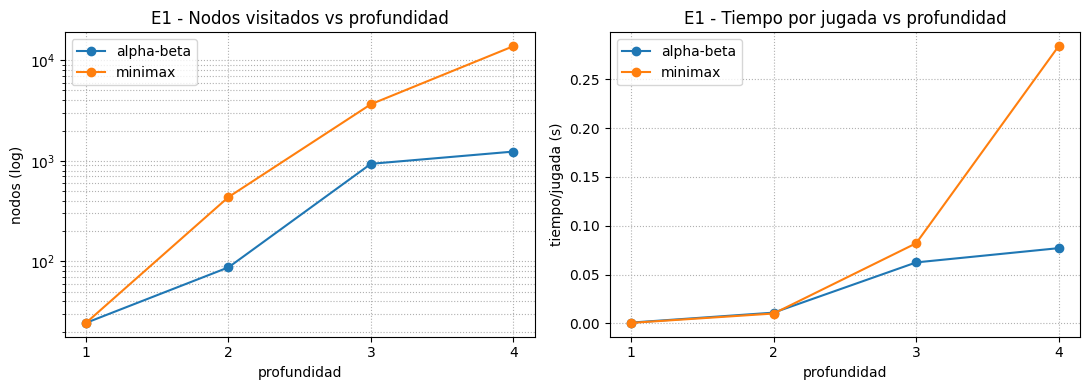

In [15]:
os.makedirs("plots", exist_ok=True)

# E1 - nodos (escala log) y tiempo por jugada vs profundidad, con vs sin Alpha-Beta.
piv_nodes = e1.groupby(["depth", "variant"])["nodes"].mean().unstack("variant")
piv_time  = e1.groupby(["depth", "variant"])["time_s"].mean().unstack("variant")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for col in piv_nodes.columns:
    axes[0].plot(piv_nodes.index, piv_nodes[col], marker="o", label=col)
axes[0].set_yscale("log"); axes[0].set_xlabel("profundidad"); axes[0].set_ylabel("nodos (log)")
axes[0].set_title("E1 - Nodos visitados vs profundidad")
axes[0].legend(); axes[0].grid(True, which="both", ls=":"); axes[0].set_xticks(piv_nodes.index)
for col in piv_time.columns:
    axes[1].plot(piv_time.index, piv_time[col], marker="o", label=col)
axes[1].set_xlabel("profundidad"); axes[1].set_ylabel("tiempo/jugada (s)")
axes[1].set_title("E1 - Tiempo por jugada vs profundidad")
axes[1].legend(); axes[1].grid(True, ls=":"); axes[1].set_xticks(piv_time.index)
fig.tight_layout(); fig.savefig("plots/e1_alpha_beta.png", dpi=120); plt.show()

/tmp/claude-501/ipykernel_51513/1818241244.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(s2["matchup"], rotation=15, ha="right")
/tmp/claude-501/ipykernel_51513/1818241244.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(s3["agent"], rotation=20, ha="right")


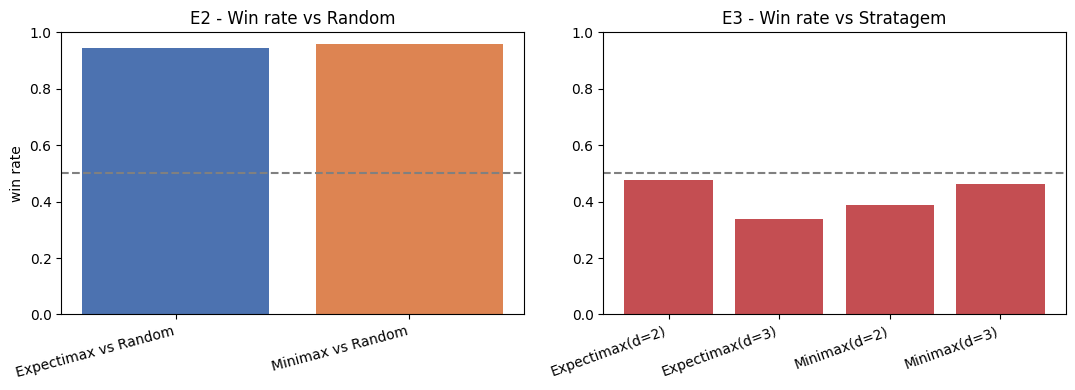

In [16]:
# E2 (vs Random) y E3 (vs Stratagem, por tecnica y profundidad): win rate en barras.
s2 = summarize(e2)
df3 = pd.DataFrame(e3)
s3 = df3.groupby("agent").agg(win_rate=("a_won", "mean")).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(s2["matchup"], s2["win_rate"], color=["#4c72b0", "#dd8452"])
axes[0].set_title("E2 - Win rate vs Random"); axes[0].set_ylim(0, 1); axes[0].set_ylabel("win rate")
axes[0].axhline(0.5, ls="--", color="gray")
axes[0].set_xticklabels(s2["matchup"], rotation=15, ha="right")
axes[1].bar(s3["agent"], s3["win_rate"], color="#c44e52")
axes[1].set_title("E3 - Win rate vs Stratagem"); axes[1].set_ylim(0, 1)
axes[1].axhline(0.5, ls="--", color="gray")
axes[1].set_xticklabels(s3["agent"], rotation=20, ha="right")
fig.tight_layout(); fig.savefig("plots/e2_e3_winrate.png", dpi=120); plt.show()

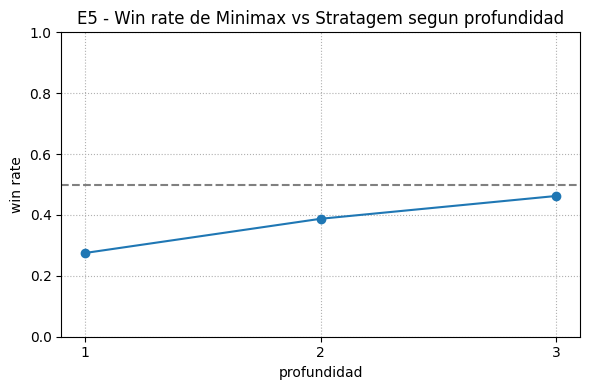

In [17]:
# E5 - win rate de Minimax vs Stratagem en funcion de la profundidad de busqueda.
df5 = pd.DataFrame(e5)
s5 = df5.groupby("depth").agg(win_rate=("a_won", "mean")).reset_index()
plt.figure(figsize=(6, 4))
plt.plot(s5["depth"], s5["win_rate"], marker="o")
plt.title("E5 - Win rate de Minimax vs Stratagem segun profundidad")
plt.xlabel("profundidad"); plt.ylabel("win rate"); plt.ylim(0, 1)
plt.axhline(0.5, ls="--", color="gray"); plt.grid(True, ls=":"); plt.xticks(s5["depth"])
plt.tight_layout(); plt.savefig("plots/e5_depth.png", dpi=120); plt.show()

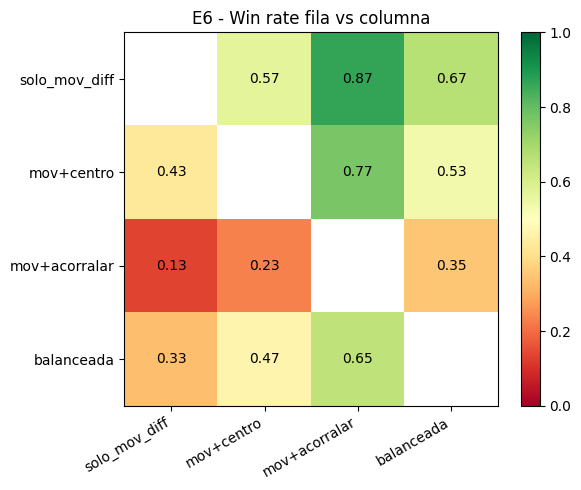

In [18]:
# E6 - heatmap del torneo de heuristicas (win rate fila vs columna).
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(mat.values.astype(float), cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        v = mat.values[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center")
ax.set_title("E6 - Win rate fila vs columna")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout(); fig.savefig("plots/e6_heatmap.png", dpi=120); plt.show()

### Modelo computado: `mate_best_config.pkl`

Minimax/Expectimax no entrenan un modelo, pero la experimentacion **computa** la mejor
configuracion de agente: tecnica ganadora, profundidad y ponderacion de heuristicas. Eso es
lo que serializamos (dict), cumpliendo la clausula de *modelos computados* de la auditoria y
haciendo **reproducible** el agente ganador. La tecnica se elige por su win rate vs Stratagem
a la mayor profundidad medida; los pesos, por el torneo E6.

In [19]:
df3 = pd.DataFrame(e3)
df3["tech"] = df3["agent"].str.split("(").str[0]
dmax = max(E3_DEPTHS)
wr_strat = df3[df3["depth"] == dmax].groupby("tech")["a_won"].mean()
best_tech = wr_strat.idxmax()                 # "Minimax" o "Expectimax" (mejor vs Stratagem a dmax)

best_weights_name = mat.mean(axis=1).idxmax() # mejor ponderacion del torneo E6
best_weights = WEIGHT_SETS[best_weights_name]
wr_rand = pd.DataFrame(e2).groupby("agent")["a_won"].mean()

best_config = {
    "tecnica": best_tech.lower(),
    "profundidad": int(dmax),
    "pesos": best_weights,
    "pesos_nombre": best_weights_name,
    "metricas": {
        "win_rate_vs_stratagem_dmax": round(float(wr_strat.max()), 3),
        "win_rate_vs_random": round(float(wr_rand.get(best_tech, float("nan"))), 3),
        "e6_mejor_winrate_promedio": round(float(mat.mean(axis=1).max()), 3),
        "N_RANDOM": N_RANDOM, "N_STRAT": N_STRAT, "N_HEUR": N_HEUR,
    },
}
with open("mate_best_config.pkl", "wb") as f:
    pickle.dump(best_config, f)

# Verificacion: recargar el .pkl (la auditoria pide poder cargar el modelo computado).
with open("mate_best_config.pkl", "rb") as f:
    loaded = pickle.load(f)
print("mate_best_config.pkl guardado y recargado OK:")
loaded

mate_best_config.pkl guardado y recargado OK:


{'tecnica': 'minimax',
 'profundidad': 3,
 'pesos': {'h2': 1.0},
 'pesos_nombre': 'solo_mov_diff',
 'metricas': {'win_rate_vs_stratagem_dmax': 0.463,
  'win_rate_vs_random': 0.96,
  'e6_mejor_winrate_promedio': 0.7,
  'N_RANDOM': 100,
  'N_STRAT': 40,
  'N_HEUR': 30}}